In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

from simplexity.generative_processes.builder import build_hidden_markov_model
from simplexity.generative_processes.generator import generate_data_batch_with_full_history
from simplexity.utils.pytorch_utils import jax_to_torch
from src.hmm.hmm import belief_to_barycentric

from tqdm.auto import tqdm
import transformer_lens as tl

/home/chiragr2/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Parameters

In [3]:
SEQ_LENGTH = 2000
HMM_CONCEPTS = ['A', 'B', 'C']
N_SEQUENCES = 10

## Build HMM & Generate Sequences

In [4]:
hmm = build_hidden_markov_model(
    "mess3",
    process_params={"x": 0.05, "a": 0.85},
    device=None,
)

print(f"Vocab size (symbols): {hmm.vocab_size}")
print(f"Num hidden states: {hmm.num_states}")
print(f"Initial state (belief): {jax_to_torch(hmm.initial_state).tolist()}")

emission_rows = []
for i in range(hmm.num_states):
    pure_state = jnp.zeros(hmm.num_states).at[i].set(1.0)
    obs_probs = hmm.observation_probability_distribution(pure_state)
    emission_rows.append(jax_to_torch(obs_probs))
emission_matrix = torch.stack(emission_rows)

print(f"\nEmission matrix (rows=states, cols=tokens A,B,C):")
print(emission_matrix)
print(f"\nRow sums (should be 1): {emission_matrix.sum(dim=1)}")

Vocab size (symbols): 3
Num hidden states: 3
Initial state (belief): [0.33333343267440796, 0.3333333134651184, 0.33333325386047363]

Emission matrix (rows=states, cols=tokens A,B,C):
tensor([[0.7725, 0.1137, 0.1137],
        [0.1137, 0.7725, 0.1137],
        [0.1138, 0.1138, 0.7725]])

Row sums (should be 1): tensor([1., 1., 1.])


In [5]:
sequence_len = SEQ_LENGTH + 1
key = jax.random.PRNGKey(42)
gen_states = jnp.tile(hmm.initial_state, (N_SEQUENCES, 1))

next_states, belief_states_jax, prefix_probs, inputs_jax, labels_jax = generate_data_batch_with_full_history(
    gen_states, hmm, N_SEQUENCES, sequence_len, key
)

tokens = jax_to_torch(inputs_jax)
tokens_y = jax_to_torch(labels_jax)
belief_states_all = jax_to_torch(belief_states_jax).cpu().numpy()
obs_probs_all_jax = jnp.einsum('bns,vst->bnv', belief_states_jax, hmm.transition_matrices)
obs_probs_all = jax_to_torch(obs_probs_all_jax)

walk_concepts = [[HMM_CONCEPTS[int(t)] for t in seq] for seq in tokens]

print(f"Num sequences: {tokens.shape[0]}, Sequence length: {tokens.shape[1]}")
print(f"First 20 tokens (seq 0): {walk_concepts[0][:20]}")
print(f"Belief states shape: {belief_states_all.shape}")
print(f"Belief states sum to 1? {np.allclose(belief_states_all.sum(axis=-1), 1)}")

Num sequences: 10, Sequence length: 2000
First 20 tokens (seq 0): ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'B', 'B', 'B', 'A', 'C', 'C', 'A', 'C', 'C', 'C', 'A', 'B']
Belief states shape: (10, 2001, 3)
Belief states sum to 1? True


## Load Model (TransformerLens)

In [6]:
MODEL_NAME = "meta-llama/Llama-3.2-3B"
N_DEVICES = min(torch.cuda.device_count(), 4)

print(f"Loading {MODEL_NAME} across {N_DEVICES} GPUs...")
model = tl.HookedTransformer.from_pretrained(
    MODEL_NAME,
    device="cuda",
    n_devices=N_DEVICES,
    torch_dtype=torch.float16,
    n_ctx=4098
)
model.eval()
print(f"Model loaded. {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
print(f"Context window: {model.cfg.n_ctx}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading meta-llama/Llama-3.2-3B across 4 GPUs...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.34it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Model loaded. 28 layers, d_model=3072
Context window: 4098


In [7]:
def get_concept_token_ids(model, concepts):
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        ids = model.to_tokens(spaced, prepend_bos=False)[0]
        concept_to_id[concept] = ids[-1].item()
    return concept_to_id

## Forward Pass (with activation caching)

In [8]:
LAYERS_TO_ANALYZE = list(range(model.cfg.n_layers))
print(f"Will analyze layers: {LAYERS_TO_ANALYZE}")

letter_set = set(HMM_CONCEPTS)

all_activations = {layer: [] for layer in LAYERS_TO_ANALYZE}
all_logits = []
all_beliefs = []
all_positions = []

for seq_idx in tqdm(range(N_SEQUENCES), desc="Processing sequences"):
    seq_concepts = walk_concepts[seq_idx]
    beliefs = belief_states_all[seq_idx]

    prompt = seq_concepts[0] + " " + " ".join(seq_concepts[1:])
    input_ids = model.to_tokens(prompt, prepend_bos=True).to(model.embed.W_E.device)
    str_tokens = model.to_str_tokens(prompt, prepend_bos=True)

    positions = [i for i, tok in enumerate(str_tokens) if tok.strip() in letter_set]

    n_use = min(len(positions), len(seq_concepts))
    if len(positions) != len(seq_concepts):
        print(f"Warning seq {seq_idx}: expected {len(seq_concepts)} letter positions, got {len(positions)}")
    positions = positions[:n_use]

    with torch.no_grad():
        _, cache = model.run_with_cache(
            input_ids,
            names_filter=[f"blocks.{l}.hook_resid_post" for l in LAYERS_TO_ANALYZE],
            return_type=None,
        )

        for layer in LAYERS_TO_ANALYZE:
            hook_name = f"blocks.{layer}.hook_resid_post"
            layer_acts = cache[hook_name][0]
            letter_acts = layer_acts[positions].cpu().float().numpy()
            all_activations[layer].append(letter_acts)

        last_resid = cache[f"blocks.{LAYERS_TO_ANALYZE[-1]}.hook_resid_post"]
        last_resid = last_resid.to(model.unembed.W_U.device)
        logits = model.unembed(model.ln_final(last_resid))
        seq_logits = logits[0, positions].cpu().float().detach().numpy()
        all_logits.append(seq_logits)
        del logits, last_resid, cache

    all_beliefs.append(beliefs[1:n_use + 1])
    all_positions.append(np.arange(n_use))
    torch.cuda.empty_cache()

for layer in LAYERS_TO_ANALYZE:
    all_activations[layer] = np.concatenate(all_activations[layer], axis=0)
all_logits_flat = np.concatenate(all_logits, axis=0)
all_beliefs_flat = np.concatenate(all_beliefs, axis=0)
all_positions_flat = np.concatenate(all_positions, axis=0)

print(f"\nTotal datapoints: {len(all_beliefs_flat)}")
print(f"Logits shape: {all_logits_flat.shape}")
print(f"Activations shape per layer: {all_activations[LAYERS_TO_ANALYZE[0]].shape}")
print(f"Beliefs shape: {all_beliefs_flat.shape}")
print(f"Position range: {all_positions_flat.min()} to {all_positions_flat.max()}")

Will analyze layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


Processing sequences: 100%|██████████| 10/10 [00:46<00:00,  4.69s/it]



Total datapoints: 20000
Logits shape: (20000, 128256)
Activations shape per layer: (20000, 3072)
Beliefs shape: (20000, 3)
Position range: 0 to 1999


## Concept Logits & KL Divergence

In [9]:
concept_to_id = get_concept_token_ids(model, HMM_CONCEPTS)
concept_ids = [concept_to_id[c] for c in HMM_CONCEPTS]
print(f"Concept token IDs (ordered): {dict(zip(HMM_CONCEPTS, concept_ids))}")

concept_logits = all_logits_flat[:, concept_ids]
llm_probs = F.softmax(torch.tensor(concept_logits), dim=-1).numpy()

print(f"Concept logits shape: {concept_logits.shape}")
print(f"LLM probs shape: {llm_probs.shape}")

Concept token IDs (ordered): {'A': 362, 'B': 426, 'C': 356}
Concept logits shape: (20000, 3)
LLM probs shape: (20000, 3)


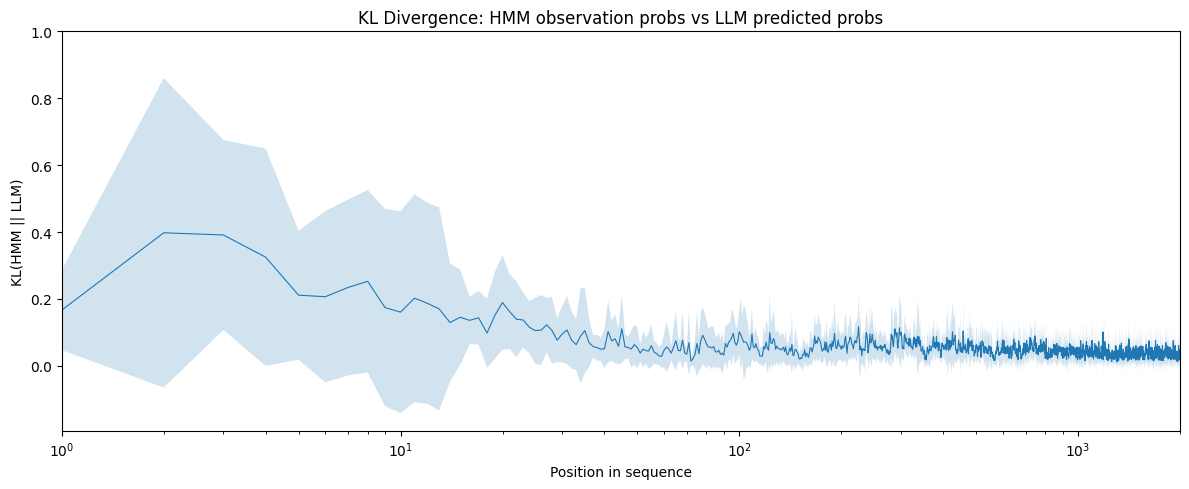

Mean KL over all positions: 0.0465
KL at position 1: 0.1665
KL at position 10: 0.1604
KL at position 100: 0.1017
KL at position 1000: 0.0356
KL at position 1999: 0.0276


In [10]:
llm_probs_3d = llm_probs.reshape(N_SEQUENCES, SEQ_LENGTH, len(HMM_CONCEPTS))
hmm_probs = obs_probs_all[:, 1:, :].cpu().numpy()

eps = 1e-10
p = np.clip(hmm_probs, eps, 1.0)
q = np.clip(llm_probs_3d, eps, 1.0)

kl_per_pos_seq = np.sum(p * np.log(p / q), axis=-1)
kl_mean = kl_per_pos_seq.mean(axis=0)
kl_std = kl_per_pos_seq.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
positions_arr = np.arange(SEQ_LENGTH)
ax.plot(positions_arr, kl_mean, linewidth=0.8)
ax.fill_between(positions_arr, kl_mean - kl_std, kl_mean + kl_std, alpha=0.2)
ax.set_xlabel('Position in sequence')
ax.set_ylabel('KL(HMM || LLM)')
ax.set_title('KL Divergence: HMM observation probs vs LLM predicted probs')
ax.set_xscale('log')
ax.set_xlim(1, SEQ_LENGTH)
ax.set_ylim(None, 1)
plt.tight_layout()
plt.show()

print(f"Mean KL over all positions: {kl_mean.mean():.4f}")
for i in [1, 10, 100, 1000, 1999]:
    print(f"KL at position {i}: {kl_mean[i]:.4f}")

## Linear Probe: Belief State Regression

In [11]:
regression_results = {}

for layer in LAYERS_TO_ANALYZE:
    acts = all_activations[layer]
    beliefs = all_beliefs_flat

    X_train, X_test, y_train, y_test = train_test_split(
        acts, beliefs, test_size=0.2, random_state=42
    )

    reg = LinearRegression()
    reg.fit(X_train, y_train)

    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    projected = reg.predict(acts)

    regression_results[layer] = {
        'model': reg,
        'mse_train': mse_train,
        'mse_test': mse_test,
        'projected': projected,
    }

    print(f"Layer {layer:2d}: MSE train={mse_train:.6f}, MSE test={mse_test:.6f}")

Layer  0: MSE train=0.000986, MSE test=0.000989
Layer  1: MSE train=0.000203, MSE test=0.000211
Layer  2: MSE train=0.000116, MSE test=0.000149
Layer  3: MSE train=0.000097, MSE test=0.000158
Layer  4: MSE train=0.000098, MSE test=0.000129
Layer  5: MSE train=0.000110, MSE test=0.000209
Layer  6: MSE train=0.000150, MSE test=0.000266
Layer  7: MSE train=0.000187, MSE test=0.000330
Layer  8: MSE train=0.000272, MSE test=0.000492
Layer  9: MSE train=0.000388, MSE test=0.000737
Layer 10: MSE train=0.000499, MSE test=0.000917
Layer 11: MSE train=0.000563, MSE test=0.000973
Layer 12: MSE train=0.000615, MSE test=0.001056
Layer 13: MSE train=0.000612, MSE test=0.001089
Layer 14: MSE train=0.000616, MSE test=0.001080
Layer 15: MSE train=0.000619, MSE test=0.001028
Layer 16: MSE train=0.000625, MSE test=0.000987
Layer 17: MSE train=0.000640, MSE test=0.001029
Layer 18: MSE train=0.000636, MSE test=0.001000
Layer 19: MSE train=0.000658, MSE test=0.001008
Layer 20: MSE train=0.000682, MSE test=0

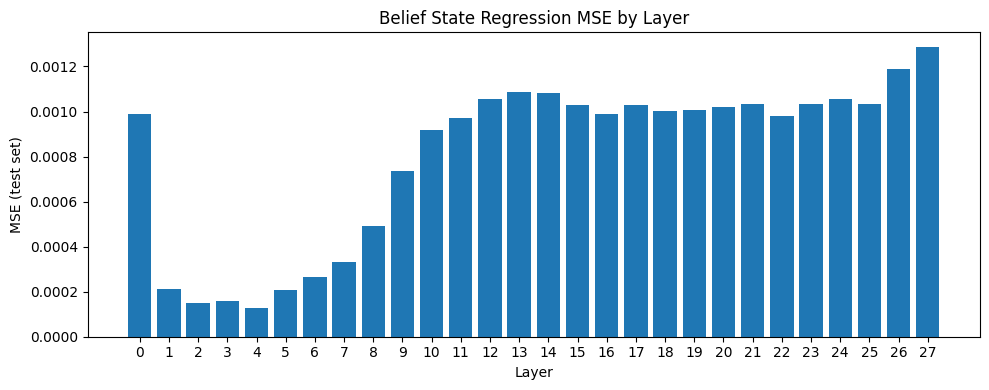

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

layers = sorted(regression_results.keys())
mse_values = [regression_results[l]['mse_test'] for l in layers]

ax.bar(range(len(layers)), mse_values, tick_label=[str(l) for l in layers])
ax.set_xlabel('Layer')
ax.set_ylabel('MSE (test set)')
ax.set_title('Belief State Regression MSE by Layer')
plt.tight_layout()
plt.show()

## PCA Analysis

Layer  0: top-3 EVR = 0.4078, 0.3319, 0.0805  |  cumulative(3) = 0.8203  cumulative(10) = 0.9842
Layer  1: top-3 EVR = 0.3218, 0.2473, 0.0875  |  cumulative(3) = 0.6565  cumulative(10) = 0.9090
Layer  2: top-3 EVR = 0.2569, 0.2182, 0.1731  |  cumulative(3) = 0.6482  cumulative(10) = 0.8742
Layer  3: top-3 EVR = 0.2491, 0.1930, 0.1487  |  cumulative(3) = 0.5908  cumulative(10) = 0.8510
Layer  4: top-3 EVR = 0.1834, 0.1784, 0.1296  |  cumulative(3) = 0.4913  cumulative(10) = 0.8290
Layer  5: top-3 EVR = 0.1768, 0.1182, 0.0892  |  cumulative(3) = 0.3842  cumulative(10) = 0.7347
Layer  6: top-3 EVR = 0.1896, 0.0988, 0.0887  |  cumulative(3) = 0.3771  cumulative(10) = 0.7164
Layer  7: top-3 EVR = 0.1244, 0.0801, 0.0757  |  cumulative(3) = 0.2803  cumulative(10) = 0.6290
Layer  8: top-3 EVR = 0.1162, 0.0733, 0.0631  |  cumulative(3) = 0.2525  cumulative(10) = 0.5370
Layer  9: top-3 EVR = 0.1172, 0.0757, 0.0602  |  cumulative(3) = 0.2531  cumulative(10) = 0.5251
Layer 10: top-3 EVR = 0.1340, 

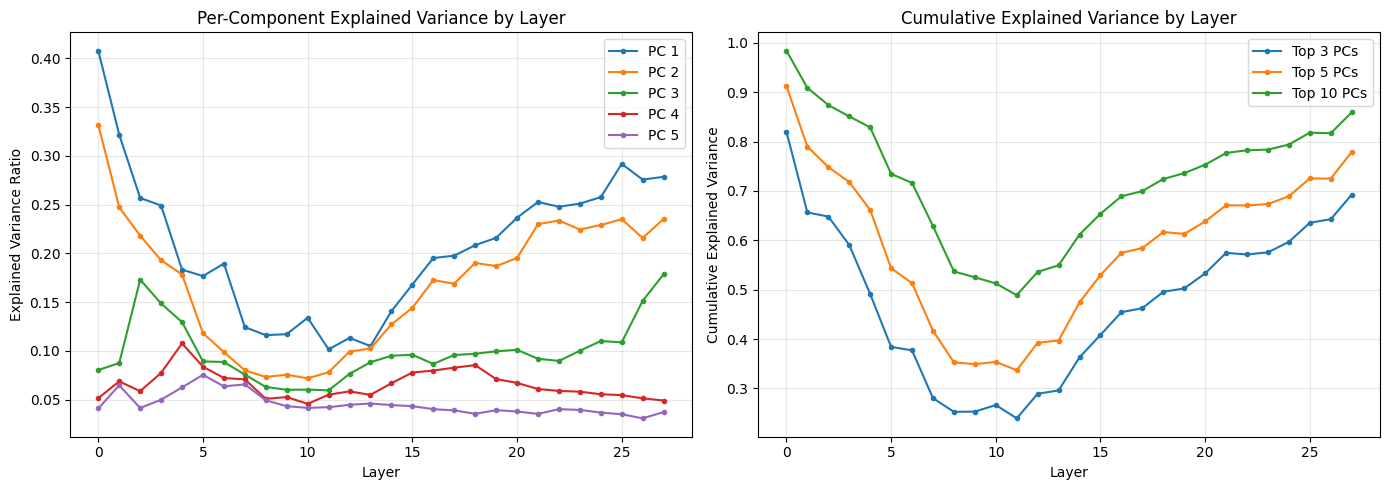

In [13]:
N_PCA_COMPONENTS = 10

pca_results = {}

for layer in LAYERS_TO_ANALYZE:
    acts = all_activations[layer]

    pca = PCA(n_components=N_PCA_COMPONENTS)
    projected = pca.fit_transform(acts)

    pca_results[layer] = {
        'model': pca,
        'projected': projected,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca.explained_variance_ratio_),
    }

    top3 = pca.explained_variance_ratio_[:3]
    cum = pca_results[layer]['cumulative_variance']
    print(f"Layer {layer:2d}: top-3 EVR = {top3[0]:.4f}, {top3[1]:.4f}, {top3[2]:.4f}  |  cumulative(3) = {cum[2]:.4f}  cumulative({N_PCA_COMPONENTS}) = {cum[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

layers_sorted = sorted(pca_results.keys())
evr_matrix = np.array([pca_results[l]['explained_variance_ratio'] for l in layers_sorted])

ax = axes[0]
for k in range(min(5, N_PCA_COMPONENTS)):
    ax.plot(layers_sorted, evr_matrix[:, k], marker='.', label=f'PC {k+1}')
ax.set_xlabel('Layer')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Per-Component Explained Variance by Layer')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
cum_matrix = np.array([pca_results[l]['cumulative_variance'] for l in layers_sorted])
for k in [2, 4, 9]:
    if k < N_PCA_COMPONENTS:
        ax.plot(layers_sorted, cum_matrix[:, k], marker='.', label=f'Top {k+1} PCs')
ax.set_xlabel('Layer')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance by Layer')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

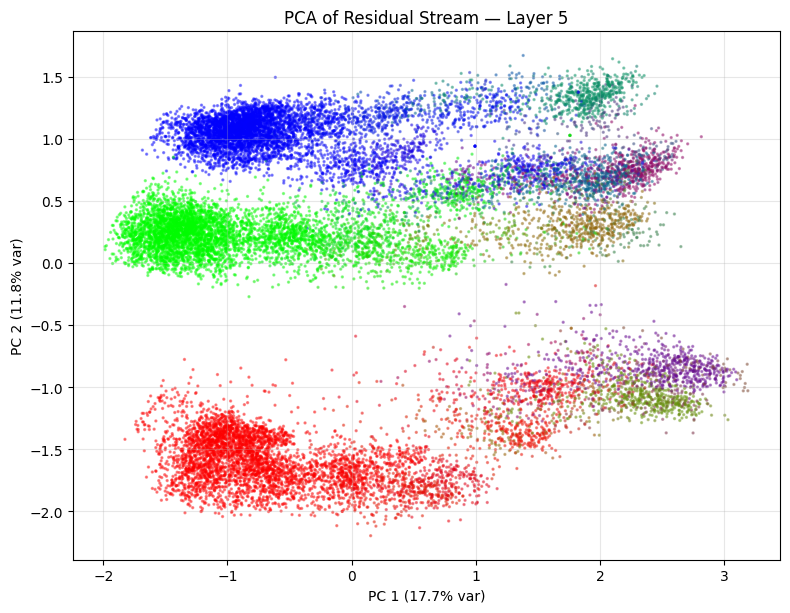

In [14]:
layer_to_plot = 5
pca_proj = pca_results[layer_to_plot]['projected'][:, :2]
evr = pca_results[layer_to_plot]['explained_variance_ratio']

beliefs_rgb = all_beliefs_flat / all_beliefs_flat.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(pca_proj[:, 0], pca_proj[:, 1], c=beliefs_rgb, s=2, alpha=0.4, rasterized=True)
ax.set_xlabel(f'PC 1 ({evr[0]:.1%} var)')
ax.set_ylabel(f'PC 2 ({evr[1]:.1%} var)')
ax.set_title(f'PCA of Residual Stream — Layer {layer_to_plot}')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Simplex Visualizations (Projected Belief States by Layer)

In [17]:
# print("Ground Truth Belief States")
# belief_to_barycentric(all_beliefs_flat.reshape(-1, 3), all_beliefs_flat.reshape(-1, 3))

# for layer in LAYERS_TO_ANALYZE:
#     projected = regression_results[layer]['projected']

#     proj_clipped = np.clip(projected, 0, 1)
#     row_sums = proj_clipped.sum(axis=1, keepdims=True)
#     row_sums[row_sums == 0] = 1
#     proj_clipped = proj_clipped / row_sums

#     mse = regression_results[layer]['mse_test']
#     print(f"Layer {layer} — MSE={mse:.4f}")
#     belief_to_barycentric(proj_clipped.reshape(-1, 3), all_beliefs_flat.reshape(-1, 3))

## Belief State Geometry for Different `a` and `x` Values on Mess3

Explore how the HMM parameters `a` (self-transition strength) and `x` (noise/confusion) affect the belief state geometry on the simplex.

In [19]:
a_values = [0.2,0.5, 0.85, 0.95]
x_values = [0.01, 0.05, 0.15, 0.5]

N_SEQ_SWEEP = 5
SWEEP_SEQ_LEN = 2000

for a in a_values:
    for x in x_values:
        hmm_sweep = build_hidden_markov_model(
            "mess3",
            process_params={"x": x, "a": a},
            device=None,
        )

        sweep_key = jax.random.PRNGKey(42)
        sweep_gen_states = jnp.tile(hmm_sweep.initial_state, (N_SEQ_SWEEP, 1))

        _, sweep_beliefs_jax, _, _, _ = generate_data_batch_with_full_history(
            sweep_gen_states, hmm_sweep, N_SEQ_SWEEP, SWEEP_SEQ_LEN + 1, sweep_key
        )

        sweep_beliefs = jax_to_torch(sweep_beliefs_jax).cpu()
        sweep_beliefs_flat = sweep_beliefs.reshape(-1, 3)

        print(f"a={a}, x={x} — {sweep_beliefs_flat.shape[0]} belief states")
        belief_to_barycentric(sweep_beliefs_flat, sweep_beliefs_flat)

a=0.2, x=0.01 — 10005 belief states


a=0.2, x=0.05 — 10005 belief states


a=0.2, x=0.15 — 10005 belief states


a=0.2, x=0.5 — 10005 belief states


a=0.5, x=0.01 — 10005 belief states


...

a=0.85, x=0.5 — 10005 belief states


a=0.95, x=0.01 — 10005 belief states


a=0.95, x=0.05 — 10005 belief states


a=0.95, x=0.15 — 10005 belief states


a=0.95, x=0.5 — 10005 belief states
